# Importation des bibliothèques

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import requests, io
import geopandas as gpd

from pyspark.sql import SparkSession
from delta import configure_spark_with_delta_pip
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pathlib import Path
from matplotlib.colors import to_rgba
from matplotlib.colors import ListedColormap

In [2]:
PALETTE = [
    '#534AB7', '#1D9E75', '#BA7517', '#D85A30',
    '#378ADD', '#D4537E', '#639922', '#E24B4A'
]

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.alpha':       0.25,
    'grid.linestyle':   '--',
    'font.size':        11,
})

# Constantes

In [3]:
# chemin pour accéder aux données
FILE_PATH = '../src/data/clean/donnees_immobilieres_cleaned.delta'

# chemin pour sauvegarder les résultats
CLASSIFICATION_OUTPUT_PATH = "../src/data/ml/classification/ministere_predictions.delta"
CLUSTERING_OUTPUT_PATH = "../src/data/ml/clustering/clusters.delta"

# chemin pour sauvegarder les figures
FIGURES_OUTPUT_PATH = "../src/data/figures/"

# Application

In [4]:
# Configuer sparksession pour utiliser delta lake
builder = (
    SparkSession.builder
    .appName("RealEstateML")
    .config("spark.sql.extensions", "io.delta.sql.DeltaSparkSessionExtension")
    .config("spark.sql.catalog.spark_catalog", "org.apache.spark.sql.delta.catalog.DeltaCatalog")
)

spark = configure_spark_with_delta_pip(builder).getOrCreate()

In [5]:
# Charger les données
df = spark.read.format("delta").load(FILE_PATH)

In [6]:
# Afficher le schéma du DataFrame
df.printSchema()

root
 |-- region: string (nullable = true)
 |-- ue: string (nullable = true)
 |-- id: string (nullable = true)
 |-- type: string (nullable = true)
 |-- fonction: string (nullable = true)
 |-- designation_batiment_terrain: string (nullable = true)
 |-- dept: string (nullable = true)
 |-- adresse: string (nullable = true)
 |-- code_postal: string (nullable = true)
 |-- ville: string (nullable = true)
 |-- pays: string (nullable = true)
 |-- ministere: string (nullable = true)
 |-- date_inventaire: date (nullable = true)



In [7]:
# Afficher les 5 premières lignes du DataFrame
df.show(5)

+-------------+--------------------+--------------------+--------------------+--------------------+----------------------------+----+-------+-----------+-----+------+--------------------+---------------+
|       region|                  ue|                  id|                type|            fonction|designation_batiment_terrain|dept|adresse|code_postal|ville|  pays|           ministere|date_inventaire|
+-------------+--------------------+--------------------+--------------------+--------------------+----------------------------+----+-------+-----------+-----+------+--------------------+---------------+
|ile de france|c0daef7745cdaf58f...|000d84e011f2b9e7e...|biens du ministèr...|biens du ministèr...|        biens du ministèr...|  93|   NULL|       NULL| NULL|France|ministère de l'In...|     2014-03-01|
|     limousin|1067ef9e24a6dcadc...|0020d6985224f09cd...|biens du ministèr...|biens du ministèr...|        biens du ministèr...|  23|   NULL|       NULL| NULL|France|ministère de l'In.

## Classification

In [8]:
# Sélection des colonnes pertinentes et suppression des lignes avec des valeurs manquantes
df_ml = df.select("type", "fonction", "region", "dept", "ministere").dropna()

In [9]:
# Indexer pour les variables catégorielles
categorical_cols = ["type", "fonction", "region", "dept"]
indexers = [
    StringIndexer(inputCol=col, outputCol=f"{col}_index", handleInvalid="keep")
    for col in categorical_cols
]

In [10]:
# Indexer pour la variable cible
label_indexer = StringIndexer(inputCol="ministere", outputCol="label", handleInvalid="keep")

In [11]:
# OneHotEncoder pour les variables catégorielles
encoder = OneHotEncoder(
    inputCols=[f"{col}_index" for col in categorical_cols],
    outputCols=[f"{col}_vec" for col in categorical_cols]
)

In [12]:
# Assemblage des features
assembler = VectorAssembler(
    inputCols=[f"{col}_vec" for col in categorical_cols],
    outputCol="features"
)

In [13]:
# Création du modèle de classification
rf = RandomForestClassifier(featuresCol="features", labelCol="label", numTrees=50)

In [14]:
# Création du pipeline
pipeline = Pipeline(stages=indexers + [label_indexer, encoder, assembler, rf])

In [15]:
# Split des données en train et test
train, test = df_ml.randomSplit([0.8, 0.2], seed=29)

In [16]:
# Entraînement du modèle
model = pipeline.fit(train)

In [17]:
# Prédictions sur le jeu de test
predictions = model.transform(test)

In [18]:
# Calcul de l'accuracy
evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

In [19]:
# Calcul de l'accuracy
accuracy = evaluator.evaluate(predictions)
print(f"Accuracy : {accuracy}")

Accuracy : 0.7026719727117681


In [20]:
# Création du dossier si il n'existe pas
Path(CLASSIFICATION_OUTPUT_PATH).parent.mkdir(parents=True, exist_ok=True)

In [21]:
# Sélection des colonnes à sauvegarder
predictions = predictions.select(
    "type",
    "region",
    "dept",
    "ministere",
    "prediction",
    "probability"
)

In [22]:
# Sauvegarde des prédictions de classification
predictions.write.format("delta").mode("overwrite").save(CLASSIFICATION_OUTPUT_PATH)

In [23]:
# Conversion des prédictions en Pandas pour visualisation
pred_pd = predictions.toPandas()

In [24]:
# Extraction de la probabilité maximale pour chaque prédiction
pred_pd['prob_max'] = pred_pd['probability'].apply(lambda v: float(max(v)))

In [25]:
# Mapping des indices de prédiction aux noms des ministères
label_model   = model.stages[4]          
label_mapping = {i: l for i, l in enumerate(label_model.labels)}
pred_pd['ministere_pred'] = pred_pd['prediction'].map(label_mapping)

In [26]:
# Affichage du nombre de lignes et de classes dans les prédictions
print(f'Classification : {len(pred_pd)} lignes, {pred_pd["ministere_pred"].nunique()} classes')

Classification : 1759 lignes, 3 classes


In [27]:
# Création du dossier si il n'existe pas
Path(FIGURES_OUTPUT_PATH).mkdir(parents=True, exist_ok=True)

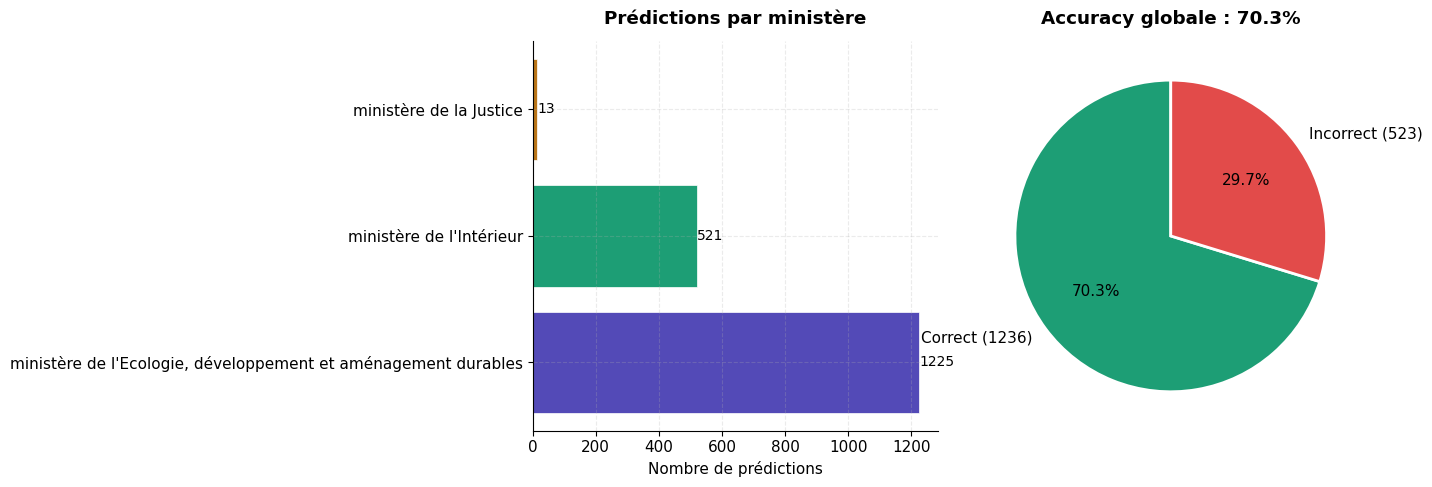

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 : prédictions par ministère 
counts = pred_pd['ministere_pred'].value_counts()
bars = axes[0].barh(
    counts.index, counts.values,
    color=PALETTE[:len(counts)], edgecolor='white', linewidth=0.5
)
axes[0].set_title('Prédictions par ministère', fontweight='bold', pad=12)
axes[0].set_xlabel('Nombre de prédictions')
for bar, val in zip(bars, counts.values):
    axes[0].text(val + 0.5, bar.get_y() + bar.get_height()/2,
                 str(val), va='center', fontsize=10)

# Graphique 2 : vrai vs prédit (matrice de confusion simplifiée) 
correct = (pred_pd['ministere'] == pred_pd['ministere_pred']).sum()
incorrect = len(pred_pd) - correct
axes[1].pie(
    [correct, incorrect],
    labels=[f'Correct ({correct})', f'Incorrect ({incorrect})'],
    colors=['#1D9E75', '#E24B4A'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title(f'Accuracy globale : {accuracy:.1%}', fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig(FIGURES_OUTPUT_PATH + 'classification_overview.png', dpi=150, bbox_inches='tight')
plt.show()


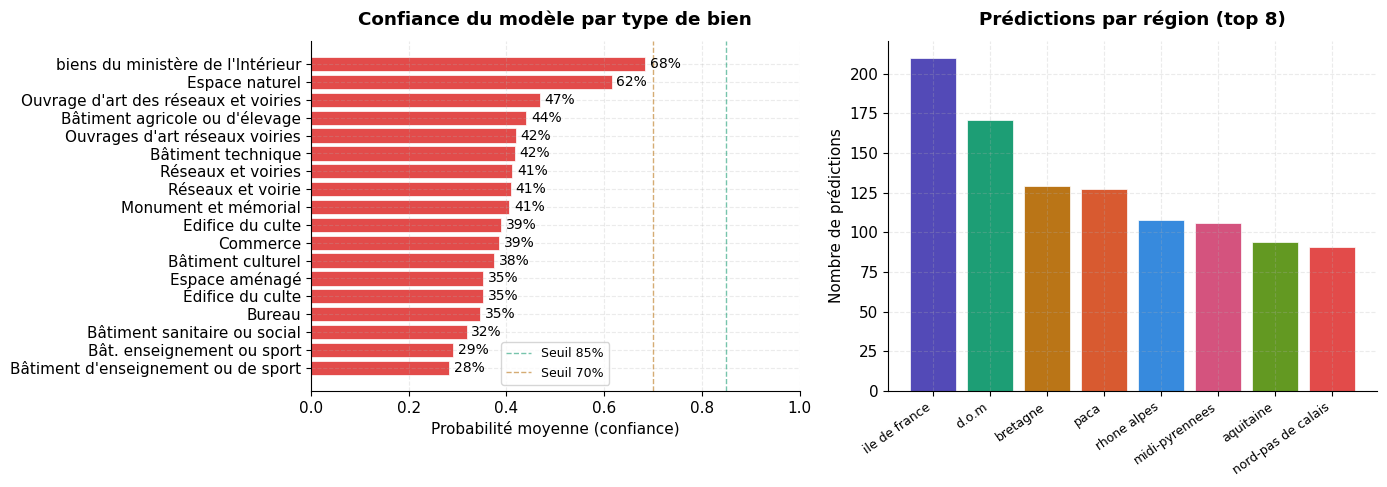

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 3 : probabilité max par type de bien 
prob_type = pred_pd.groupby('type')['prob_max'].mean().sort_values(ascending=True)
colors_type = ['#1D9E75' if v >= 0.85 else '#BA7517' if v >= 0.70 else '#E24B4A'
               for v in prob_type.values]
axes[0].barh(prob_type.index, prob_type.values, color=colors_type,
             edgecolor='white', linewidth=0.5)
axes[0].axvline(0.85, color='#1D9E75', linestyle='--', linewidth=1, alpha=0.6, label='Seuil 85%')
axes[0].axvline(0.70, color='#BA7517', linestyle='--', linewidth=1, alpha=0.6, label='Seuil 70%')
axes[0].set_xlim(0, 1)
axes[0].set_xlabel('Probabilité moyenne (confiance)')
axes[0].set_title('Confiance du modèle par type de bien', fontweight='bold', pad=12)
axes[0].legend(fontsize=9)
for i, (idx, val) in enumerate(prob_type.items()):
    axes[0].text(val + 0.01, i, f'{val:.0%}', va='center', fontsize=10)

# Graphique 4 : répartition des prédictions par région 
top_regions = pred_pd['region'].value_counts().head(8)
axes[1].bar(range(len(top_regions)), top_regions.values,
            color=PALETTE[:len(top_regions)], edgecolor='white', linewidth=0.5)
axes[1].set_xticks(range(len(top_regions)))
axes[1].set_xticklabels(top_regions.index, rotation=35, ha='right', fontsize=9)
axes[1].set_title('Prédictions par région (top 8)', fontweight='bold', pad=12)
axes[1].set_ylabel('Nombre de prédictions')

plt.tight_layout()
plt.savefig(FIGURES_OUTPUT_PATH + 'classification_detail.png', dpi=150, bbox_inches='tight')
plt.show()


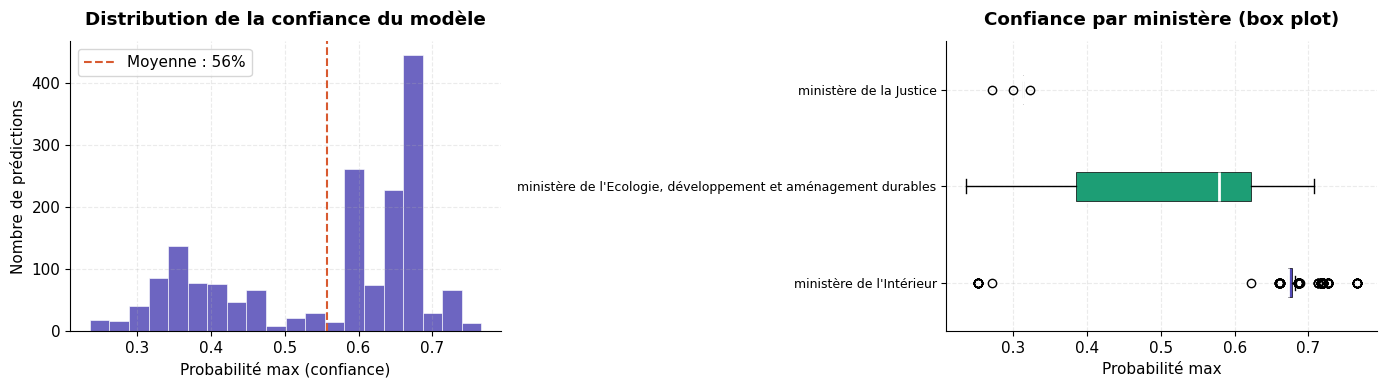

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

#  Graphique 5 : histogramme des probabilités 
axes[0].hist(pred_pd['prob_max'], bins=20, color='#534AB7',
             edgecolor='white', linewidth=0.5, alpha=0.85)
axes[0].axvline(pred_pd['prob_max'].mean(), color='#D85A30', linestyle='--',
                linewidth=1.5, label=f'Moyenne : {pred_pd["prob_max"].mean():.0%}')
axes[0].set_xlabel('Probabilité max (confiance)')
axes[0].set_ylabel('Nombre de prédictions')
axes[0].set_title('Distribution de la confiance du modèle', fontweight='bold', pad=12)
axes[0].legend()

#  Graphique 6 : box plot probabilité par ministère 
ministeres_order = pred_pd.groupby('ministere_pred')['prob_max'].median().sort_values(ascending=False).index
data_box = [pred_pd[pred_pd['ministere_pred'] == m]['prob_max'].values for m in ministeres_order]
bp = axes[1].boxplot(data_box, vert=False, patch_artist=True,
                     boxprops=dict(linewidth=0.5),
                     medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(color)
axes[1].set_yticks(range(1, len(ministeres_order)+1))
axes[1].set_yticklabels(ministeres_order, fontsize=9)
axes[1].set_xlabel('Probabilité max')
axes[1].set_title('Confiance par ministère (box plot)', fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig(FIGURES_OUTPUT_PATH + 'classification_proba.png', dpi=150, bbox_inches='tight')
plt.show()


## Clustering

In [31]:
# Sélection des colonnes pertinentes pour le clustering et suppression des lignes avec des valeurs manquantes
df_cluster = df.select("type", "fonction", "region", "dept", "ministere").dropna()

In [32]:
# Indexer pour les variables catégorielles
categorical_cols = ["type", "fonction", "region", "dept", "ministere"]

indexers = [
    StringIndexer(inputCol=col, outputCol=f"{col}_index")
    for col in categorical_cols
]

In [33]:
# OneHotEncoder pour les variables catégorielles
encoder = OneHotEncoder(
    inputCols=[f"{col}_index" for col in categorical_cols],
    outputCols=[f"{col}_vec" for col in categorical_cols]
)

In [34]:
# Assemblage des features
assembler = VectorAssembler(
    inputCols=[f"{col}_vec" for col in categorical_cols],
    outputCol="features"
)

In [35]:
# Création du modèle de clustering
kmeans = KMeans(k=5, seed=29)

In [36]:
# Création du pipeline
pipeline = Pipeline(stages=indexers + [encoder, assembler, kmeans])

In [37]:
# Entraînement du modèle de clustering
model = pipeline.fit(df_cluster)

In [38]:
# Prédictions de clustering
cluster_predictions = model.transform(df_cluster)

In [39]:
# Affichage des prédictions de clustering
cluster_predictions.select("type", "region", "prediction").show()

+--------------------+--------------------+----------+
|                type|              region|prediction|
+--------------------+--------------------+----------+
|biens du ministèr...|       ile de france|         1|
|biens du ministèr...|            limousin|         1|
|biens du ministèr...|              alsace|         1|
|biens du ministèr...|              poitou|         1|
|biens du ministèr...|         rhone alpes|         1|
|biens du ministèr...|              centre|         1|
|biens du ministèr...|            bretagne|         1|
|biens du ministèr...|       ile de france|         1|
|biens du ministèr...|languedoc-roussillon|         1|
|biens du ministèr...|      midi-pyrennees|         1|
|biens du ministèr...|           bourgogne|         1|
|biens du ministèr...|                paca|         1|
|biens du ministèr...|languedoc-roussillon|         1|
|biens du ministèr...|               d.o.m|         1|
|biens du ministèr...|  champagne-ardennes|         1|
|biens du 

In [40]:
# Création du dossier si il n'existe pas
cluster_predictions = cluster_predictions.select(
    "type",
    "region",
    "dept",
    "ministere",
    "prediction"  
)

In [41]:
# Sauvegarde des prédictions de clustering
Path(CLUSTERING_OUTPUT_PATH).parent.mkdir(parents=True, exist_ok=True)

In [42]:
# Sauvegarde des prédictions de clustering
cluster_predictions.write.format("delta").mode("overwrite").save(CLUSTERING_OUTPUT_PATH)

In [43]:
# Conversion des prédictions de clustering en Pandas pour visualisation
cluster_pd = cluster_predictions.toPandas()

In [44]:
# Mapping des indices de prédiction aux noms des ministères
label_model   = model.stages[4]          
label_mapping = {i: l for i, l in enumerate(label_model.labels)}

In [45]:
# Affichage du nombre de lignes et de clusters dans les prédictions de clustering
print(f'Clustering     : {len(cluster_pd)} lignes, {cluster_pd["prediction"].nunique()} clusters')

Clustering     : 8881 lignes, 5 clusters


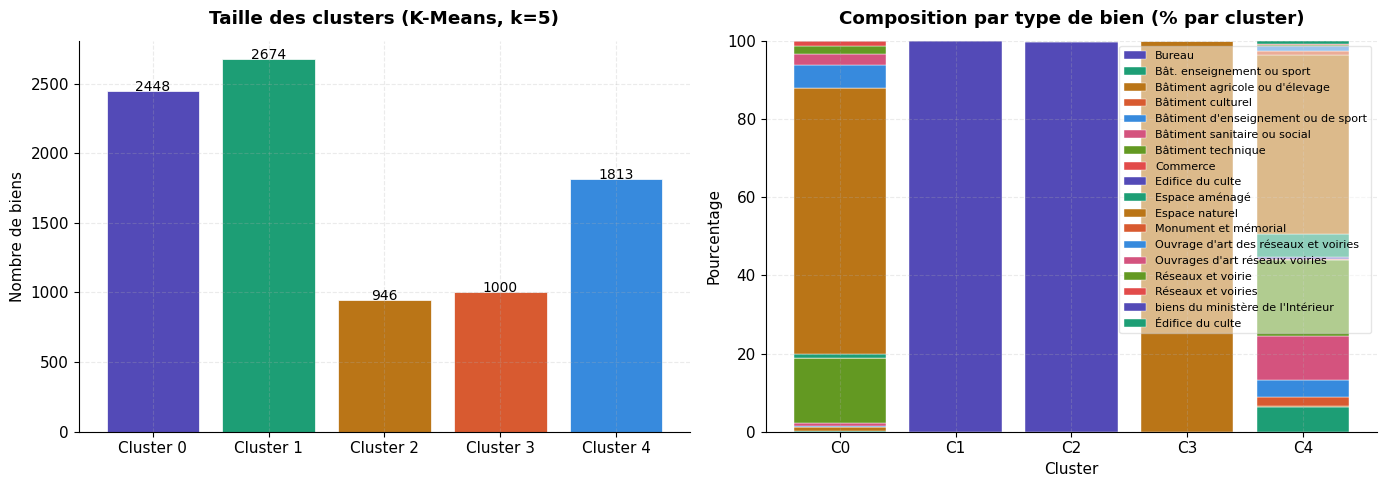

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 7 : taille des clusters 
cluster_counts = cluster_pd['prediction'].value_counts().sort_index()
cluster_labels = [f'Cluster {i}' for i in cluster_counts.index]
axes[0].bar(cluster_labels, cluster_counts.values,
            color=PALETTE[:len(cluster_counts)], edgecolor='white', linewidth=0.5)
axes[0].set_title('Taille des clusters (K-Means, k=5)', fontweight='bold', pad=12)
axes[0].set_ylabel('Nombre de biens')
for i, val in enumerate(cluster_counts.values):
    axes[0].text(i, val + 1, str(val), ha='center', fontsize=10)

# Graphique 8 : composition type de bien par cluster 
crosstab_type = pd.crosstab(cluster_pd['prediction'], cluster_pd['type'], normalize='index') * 100
bottom = np.zeros(len(crosstab_type))
for j, col in enumerate(crosstab_type.columns):
    axes[1].bar(crosstab_type.index, crosstab_type[col],
                bottom=bottom, label=col,
                color=PALETTE[j % len(PALETTE)], edgecolor='white', linewidth=0.3)
    bottom += crosstab_type[col].values
axes[1].set_title('Composition par type de bien (% par cluster)', fontweight='bold', pad=12)
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Pourcentage')
axes[1].legend(loc='upper right', fontsize=8, framealpha=0.5)
axes[1].set_xticks(crosstab_type.index)
axes[1].set_xticklabels([f'C{i}' for i in crosstab_type.index])

plt.tight_layout()
plt.savefig(FIGURES_OUTPUT_PATH + 'clustering_overview.png', dpi=150, bbox_inches='tight')
plt.show()

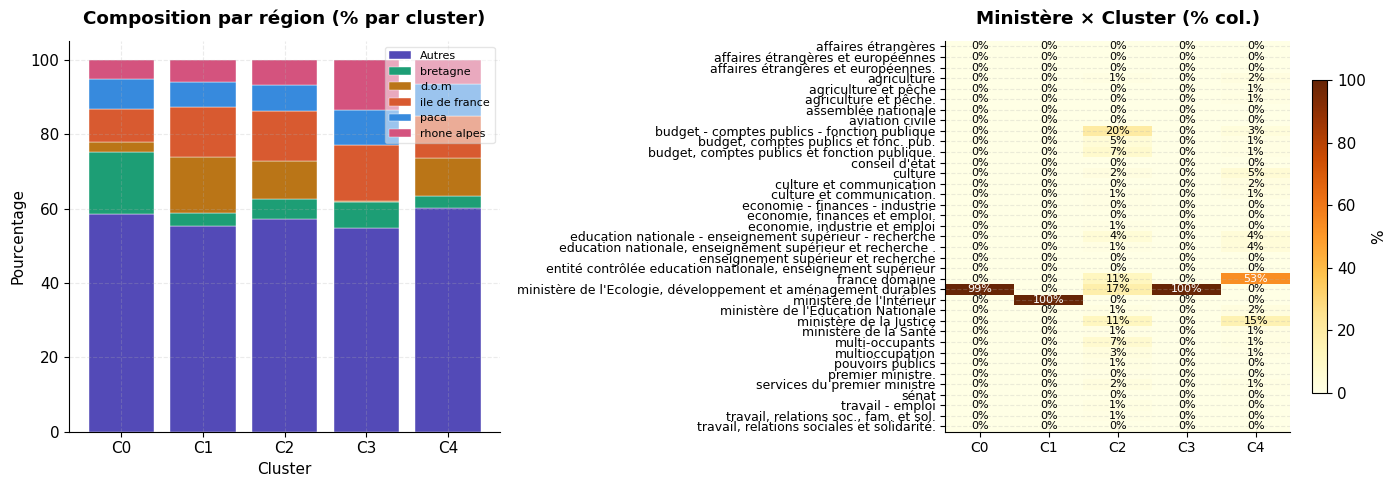

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 9 : top régions par cluster 
top_reg = cluster_pd['region'].value_counts().head(5).index
cluster_region = pd.crosstab(
    cluster_pd['prediction'],
    cluster_pd['region'].where(cluster_pd['region'].isin(top_reg), other='Autres'),
    normalize='index'
) * 100
bottom = np.zeros(len(cluster_region))
for j, col in enumerate(cluster_region.columns):
    axes[0].bar(cluster_region.index, cluster_region[col],
                bottom=bottom, label=col,
                color=PALETTE[j % len(PALETTE)], edgecolor='white', linewidth=0.3)
    bottom += cluster_region[col].values
axes[0].set_title('Composition par région (% par cluster)', fontweight='bold', pad=12)
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Pourcentage')
axes[0].legend(loc='upper right', fontsize=8, framealpha=0.5)
axes[0].set_xticks(cluster_region.index)
axes[0].set_xticklabels([f'C{i}' for i in cluster_region.index])

# Graphique 10 : heatmap ministère × cluster 
heat = pd.crosstab(cluster_pd['ministere'], cluster_pd['prediction'], normalize='columns') * 100
im = axes[1].imshow(heat.values, aspect='auto', cmap='YlOrBr')
axes[1].set_xticks(range(len(heat.columns)))
axes[1].set_xticklabels([f'C{c}' for c in heat.columns], fontsize=10)
axes[1].set_yticks(range(len(heat.index)))
axes[1].set_yticklabels(heat.index, fontsize=9)
axes[1].set_title('Ministère × Cluster (% col.)', fontweight='bold', pad=12)
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        val = heat.values[i, j]
        axes[1].text(j, i, f'{val:.0f}%',
                     ha='center', va='center', fontsize=8,
                     color='white' if val > 40 else 'black')
plt.colorbar(im, ax=axes[1], shrink=0.8, label='%')

plt.tight_layout()
plt.savefig(FIGURES_OUTPUT_PATH +'clustering_detail.png', dpi=150, bbox_inches='tight')
plt.show()

In [48]:
url = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/departements-version-simplifiee.geojson"
geo_df = gpd.read_file(url)

In [49]:
cluster_by_dept = (
    cluster_pd
    .groupby('dept')['prediction']
    .agg(lambda x: x.value_counts().idxmax())   
    .reset_index()
    .rename(columns={'prediction': 'cluster_dominant'})
)

In [50]:
count_by_dept = cluster_pd.groupby('dept').size().reset_index(name='nb_biens')
cluster_by_dept = cluster_by_dept.merge(count_by_dept, on='dept')

In [51]:
cluster_by_dept['dept_code'] = cluster_by_dept['dept'].str.zfill(2)
geo_merged = geo_df.merge(cluster_by_dept, left_on='code', right_on='dept_code', how='left')

In [52]:
cmap = ListedColormap(PALETTE)


NameError: name 'ListedColormap' is not defined

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Carte gauche : cluster dominant par département 
geo_merged.plot(
    column='cluster_dominant',
    ax=axes[0],
    cmap=cmap,
    edgecolor='white',
    linewidth=0.4,
    missing_kwds={'color': '#e0e0e0', 'label': 'Aucune donnée'}
)
axes[0].set_title('Cluster dominant par département', fontweight='bold', fontsize=13, pad=12)
axes[0].axis('off')

# Légende manuelle
legend_patches = [
    mpatches.Patch(color=PALETTE[i], label=f'Cluster {i}')
    for i in range(5)
]
legend_patches.append(mpatches.Patch(color='#e0e0e0', label='Aucune donnée'))
axes[0].legend(handles=legend_patches, loc='lower left', fontsize=9,
               framealpha=0.8, title='Clusters', title_fontsize=10)

# Carte droite : nombre de biens par département
geo_merged.plot(
    column='nb_biens',
    ax=axes[1],
    cmap='YlOrBr',
    edgecolor='white',
    linewidth=0.4,
    legend=True,
    missing_kwds={'color': '#e0e0e0'},
    legend_kwds={'label': 'Nombre de biens', 'shrink': 0.6}
)
axes[1].set_title('Nombre de biens immobiliers par département', fontweight='bold', fontsize=13, pad=12)
axes[1].axis('off')

plt.suptitle('Analyse géographique des clusters — Biens immobiliers de l\'État',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_OUTPUT_PATH + 'carte_clusters_france.png', dpi=150, bbox_inches='tight')
plt.show()